# X-ray diseases classifier

This notebook demonstrates an image classification approach for analyzing chest X-ray images. The project uses the NIH Chest X-ray dataset and focuses on exploring a proof-of-concept method for detecting thoracic findings from medical imaging data.

Rabi Arbi, 2026

![banner](https://d1qpnt4t1p05jk.cloudfront.net/wp-content/uploads/2025/10/27082644/image-2544-1024x683.jpeg)

In [1]:
import collections, lightning, pandas as pd, platform, os, torch, torchvision, warnings

from torch.utils.data import Dataset, DataLoader
from lightning import LightningDataModule, LightningModule, Trainer
from torchvision import transforms
from torchmetrics.classification import MultilabelAccuracy, MultilabelPrecision, MultilabelRecall
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

import matplotlib.pyplot as plt

lightning.seed_everything(42)
torch.set_float32_matmul_precision("high")

data_path = "data"

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

trainer_kwargs = {
    "accelerator": "gpu" if use_cuda else "cpu",
    "devices": 1,
}

if use_cuda:
    trainer_kwargs["precision"] = "16-mixed"

print(
    "Versions: python", platform.python_version(),
    "| torch", torch.__version__,
    "| torchvision", torchvision.__version__,
    "| lightning", lightning.__version__,
)
print("CUDA available:", use_cuda)
print("Active device:", device)
print("GPU:", torch.cuda.get_device_name(0) if use_cuda else "N/A")
print("Trainer kwargs:", trainer_kwargs)

W0407 23:39:28.672000 33340 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


W0407 23:39:28.672000 33340 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


Versions: python 3.14.0 | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | lightning 2.6.1
CUDA available: True
Active device: cuda
GPU: NVIDIA GeForce RTX 5080
Trainer kwargs: {'accelerator': 'gpu', 'devices': 1, 'precision': '16-mixed'}


### explanation

- `collections` → counts labels and checks class balance  
- `lightning` → organizes training structure  
- `pandas` → reads and processes the dataset CSV  
- `platform` → shows Python/version info  
- `os` → handles file paths  
- `torch` → core deep learning library  
- `torchvision` → image utilities and transforms  
- `warnings` → controls warning messages  

- `Dataset` → builds a custom NIH dataset class  
- `DataLoader` → loads images in batches  

- `LightningDataModule` → manages data loading and splits  
- `LightningModule` → defines model, loss, and training steps  
- `Trainer` → runs training and validation  

- `transforms` → preprocesses X-ray images  
- `MultilabelAccuracy` → evaluates multi-label predictions  
- `MultilabelPrecision` → checks how many positive predictions are correct  
- `MultilabelRecall` → checks how many real positives are found  

- `CSVLogger` → saves training results  
- `EarlyStopping` → stops training when improvement stalls  
- `matplotlib.pyplot` → plots images and training curves  

- `seed_everything(42)` → makes runs reproducible  
- `set_float32_matmul_precision("high")` → improves GPU computation performance  
- `data_path = "data"` → sets dataset folder  
- `print(...)` → shows library versions

------------------------------------------------------------------------------------

# Loading a pre-trained model

In [2]:
import torch.nn as nn
import torchvision

num_classes = 14

pretrained_model = torchvision.models.efficientnet_v2_s(weights="DEFAULT")
in_features = pretrained_model.classifier[1].in_features
pretrained_model.classifier[1] = nn.Linear(in_features, num_classes)

criterion = nn.CrossEntropyLoss()

## What each part does:

- `resnet50(weights="DEFAULT")` → loads the original pretrained ResNet50
- `nn.Linear(...)` → replaces the last layer with 14 outputs
- `num_classes` = 14 → one output per chest finding class
- `CrossEntropyLoss()` → simple loss for single-label classification

### Why the last layer was replaced

The old last layer was built for a different task.

This pretrained `ResNet50` came from ImageNet, so its final layer was made to predict **1000 ImageNet classes** such as dogs, cars, chairs, and other everyday objects.

This project is different:
- **input** = chest X-ray image  
- **output** = 14 thoracic findings  

So the original last layer does not match this target.

Inside the model:
- the early and middle layers learn general visual features  
- the last layer maps those features to the final class outputs  

That last mapping is task-specific.

The last layer was replaced because:
- the ImageNet output size is wrong  
- this project needs **14 outputs**  
- the new classes are completely different  
- this is how transfer learning adapts a pretrained model to a new task  

Simple example:

**Before**
- model sees an image  
- final layer predicts one of **1000 ImageNet classes**  

**After**
- model sees a chest X-ray  
- final layer predicts the 14 chest findings, such as **Atelectasis, Effusion, Mass, Pneumonia**, and others.

------------------------------------------------------------------------------------------------------

## Clean The Data


### No Finding Analysis

We will measure how many images are labeled **No Finding**. These samples may add less value for disease classification, so we review their proportion before deciding whether to keep or remove them.

In [3]:
from pathlib import Path

# Locate NIH metadata CSV from common project layouts.
candidate_csv_paths = [
    Path(data_path) / "Data_Entry_2017.csv",
    Path("Data_Entry_2017.csv"),
    Path("archive") / "Data_Entry_2017.csv",
]

csv_path = next((p for p in candidate_csv_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find Data_Entry_2017.csv. Checked: "
        + ", ".join(str(p) for p in candidate_csv_paths)
    )

df = pd.read_csv(csv_path)

if "Finding Labels" not in df.columns:
    raise KeyError("Column 'Finding Labels' was not found in the metadata CSV.")

no_finding_mask = df["Finding Labels"].fillna("").str.strip().eq("No Finding")
no_finding_count = int(no_finding_mask.sum())
total_images = len(df)
other_findings_count = total_images - no_finding_count
no_finding_ratio = (no_finding_count / total_images) if total_images else 0.0

summary_table = pd.DataFrame(
    {
        "Metric": [
            "CSV used",
            "Total images",
            "Images with No Finding",
            "Images with Other Findings",
            "No Finding ratio",
        ],
        "Value": [
            str(csv_path),
            f"{total_images:,}",
            f"{no_finding_count:,}",
            f"{other_findings_count:,}",
            f"{no_finding_ratio:.2%}",
        ],
    }
)
display(summary_table)



,Metric,Value
0,CSV used,Data_Entry_2017.csv
1,Total images,"112,120"
2,Images with No Finding,"60,361"
3,Images with Other Findings,"51,759"
4,No Finding ratio,53.84%


### Why It Can Be Better to Remove Some No Finding Images:
In this task, removing a portion of **No Finding** images can improve learning because the model then sees more disease-positive examples, reducing class imbalance and helping it focus on patterns related to thoracic abnormalities.

In [4]:
# Prints only the number of images after removal (skip if removal not run yet).
if "total_after" in globals():
    print(total_after)
elif "df_clean" in globals():
    total_after = len(df_clean)
    print(total_after)
else:
    print("No Finding removal has not run yet. Skipping count.")

No Finding removal has not run yet. Skipping count.


In [5]:
# Remove all rows labeled 'No Finding'. Skip if already removed.
if "df_clean" in globals() and "total_after" in globals():
    print("No Finding rows already removed. Skipping.")
else:
    if "df" not in globals():
        raise NameError("Run the metadata loading cell first to create df.")

    if "Finding Labels" not in df.columns:
        raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

    no_finding_mask = df["Finding Labels"].fillna("").str.strip().eq("No Finding")
    df_clean = df.loc[~no_finding_mask].copy()

    total_before = len(df)
    total_after = len(df_clean)
    removed_count = total_before - total_after

    print(f"Total images before: {total_before}")
    print(f"No Finding images removed: {removed_count}")
    print(f"Total images after removal: {total_after}")


Total images before: 112120
No Finding images removed: 60361
Total images after removal: 51759


# Chart: total images before any cleaning vs final images after all cleaning.


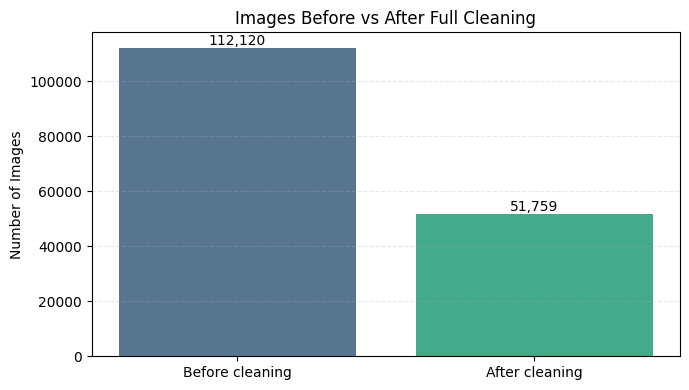

Before cleaning: 112120
After cleaning (all disease rows): 51759


In [6]:
before_cleaning = len(df) if "df" in globals() else total_images

if "df_clean" in globals():
    after_cleaning = len(df_clean)
elif "df" in globals() and "Finding Labels" in df.columns:
    after_cleaning = len(
        df.loc[
            ~df["Finding Labels"].fillna("").astype(str).str.strip().str.casefold().eq("no finding")
        ]
    )
else:
    after_cleaning = final_photos_kept if "final_photos_kept" in globals() else 0

labels = ["Before cleaning", "After cleaning"]
values = [before_cleaning, after_cleaning]
colors = ["#577590", "#43aa8b"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=colors)
plt.title("Images Before vs After Full Cleaning")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print(f"Before cleaning: {before_cleaning}")
print(f"After cleaning (all disease rows): {after_cleaning}")

# Randomly show 10 images and their labels (sampled from all cleaned disease rows).

In [7]:
from pathlib import Path
import pandas as pd

# Use all disease rows (multi-label kept), not one-image-per-patient.
if "df_clean" in globals():
    sample_df = df_clean.copy()
elif "df" in globals():
    sample_df = df.copy()
else:
    csv_candidates = [
        Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
        Path("Data_Entry_2017.csv"),
        Path("archive") / "Data_Entry_2017.csv",
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError("Could not find Data_Entry_2017.csv")
    sample_df = pd.read_csv(csv_path)

required_cols = ["Image Index", "Finding Labels"]
missing_cols = [c for c in required_cols if c not in sample_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

sample_df["Finding Labels"] = sample_df["Finding Labels"].fillna("").astype(str).str.strip()
sample_df = sample_df.loc[
    sample_df["Finding Labels"].ne("")
    & ~sample_df["Finding Labels"].str.casefold().eq("no finding")
].copy()

total_images_kept = len(sample_df)
n = min(10, total_images_kept)
random_10 = sample_df.sample(n=n, random_state=42).loc[:, ["Image Index", "Finding Labels"]]
random_10 = random_10.reset_index(drop=True)

print(f"Total disease rows after cleaning: {total_images_kept}")
print(f"Random sample of {n} images (from all cleaned rows):")
display(random_10)

Total disease rows after cleaning: 51759
Random sample of 10 images (from all cleaned rows):


,Image Index,Finding Labels
0,00009305_001.png,Mass
1,00020703_027.png,Effusion|Mass|Nodule
2,00012834_008.png,Atelectasis|Consolidation|Effusion|Infiltration
3,00016064_004.png,Emphysema
4,00011702_006.png,Atelectasis|Effusion|Infiltration
5,00014613_001.png,Infiltration
6,00001684_023.png,Atelectasis
7,00012841_000.png,Pleural_Thickening
8,00000181_011.png,Atelectasis|Infiltration|Pleural_Thickening
9,00012863_008.png,Consolidation|Infiltration


## Number of images Per class

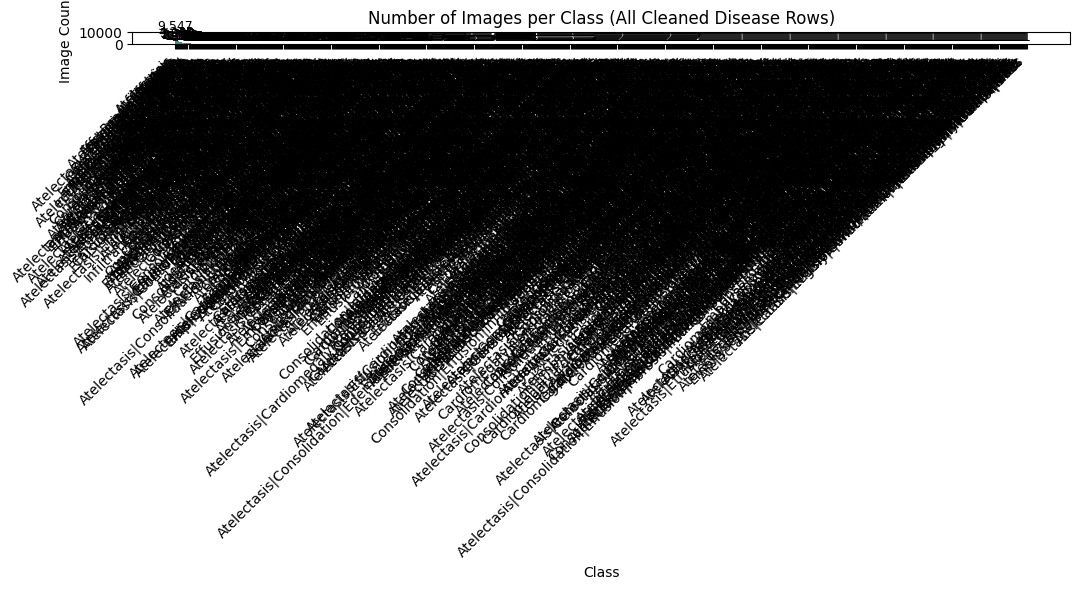

Total rows used for plotting: 51,759
Total labels counted: 51,759
Total unique classes: 835


In [8]:
# Number of images per class after cleaning (excluding 'No Finding')
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def build_clean_df(base_df: pd.DataFrame) -> pd.DataFrame:
    if "Finding Labels" not in base_df.columns:
        raise KeyError("Column 'Finding Labels' not found in the dataframe.")

    disease_df = base_df.loc[
        ~base_df["Finding Labels"].fillna("").astype(str).str.strip().str.casefold().eq("no finding")
    ].copy()
    return disease_df

if "df_clean" in globals():
    plot_df = df_clean.copy()
elif "df" in globals():
    plot_df = build_clean_df(df.copy())
else:
    csv_candidates = [
        Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
        Path("Data_Entry_2017.csv"),
        Path("archive") / "Data_Entry_2017.csv",
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError("Could not find Data_Entry_2017.csv")
    plot_df = build_clean_df(pd.read_csv(csv_path))

class_counts = (
    plot_df["Finding Labels"]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s.ne("") & s.str.casefold().ne("no finding")]
    .value_counts()
    .sort_values(ascending=False)
)

if class_counts.empty:
    raise ValueError("No disease labels found after cleaning.")

plt.figure(figsize=(11, 6))
bars = plt.bar(class_counts.index, class_counts.values, color="#2a9d8f")
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count:,}", ha="center", va="bottom", fontsize=9)

plt.title("Number of Images per Class (All Cleaned Disease Rows)")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Total rows used for plotting: {len(plot_df):,}")
print(f"Total labels counted: {int(class_counts.sum()):,}")
print(f"Total unique classes: {class_counts.size}")

# Resize the images
 the images sizes are Too big (1024 * 1024) it will get too heavy to train the model the best solution is to resize it down to 512 * 512

In [9]:
from pathlib import Path
from PIL import Image

# Resize all cleaned disease images (multi-label kept), not one-image-per-patient.
if "df_clean" in globals():
    resize_df = df_clean.copy()
elif "df" in globals():
    resize_df = df.copy()
else:
    raise NameError("Run metadata loading/cleaning cells first to create df or df_clean.")

if "Image Index" not in resize_df.columns:
    raise KeyError("Column 'Image Index' not found in the dataframe.")
if "Finding Labels" in resize_df.columns:
    resize_df = resize_df.loc[
        ~resize_df["Finding Labels"].fillna("").astype(str).str.strip().str.casefold().eq("no finding")
    ].copy()

target_size = (512, 512)

# Support running notebook either from project root or from archive/ folder.
base_candidates = [Path("."), Path("archive")]
image_roots = []
for base in base_candidates:
    image_roots.extend(sorted(base.glob("images_*/images")))

if not image_roots:
    raise FileNotFoundError("Could not find any source folders matching images_*/images.")

output_base = Path("archive") if Path("archive").exists() else Path(".")
output_dir = output_base / "images_512"
output_dir.mkdir(parents=True, exist_ok=True)

# Build fast lookup for original image files across NIH folders.
image_lookup = {}
for root in image_roots:
    for p in root.glob("*.png"):
        image_lookup[p.name] = p

image_names = resize_df["Image Index"].dropna().astype(str).unique().tolist()

# Check if all images are already resized; if so, skip the operation entirely.
already_resized = [img_name for img_name in image_names if (output_dir / img_name).exists()]
if len(already_resized) == len(image_names):
    print(f"All {len(image_names)} images are already resized to {target_size}. Skipping resize operation.")
    print(f"Output folder: {output_dir}")
else:
    resized_count = 0
    missing_count = 0
    skipped_count = 0

    for img_name in image_names:
        src = image_lookup.get(img_name)
        if src is None:
            missing_count += 1
            continue

        dst = output_dir / img_name
        if dst.exists():
            skipped_count += 1
            continue

        with Image.open(src) as im:
            im = im.convert("RGB")
            im = im.resize(target_size, Image.Resampling.LANCZOS)
            im.save(dst, format="PNG")
        resized_count += 1

    print(f"Target size: {target_size}")
    print(f"Source unique images: {len(image_names)}")
    print(f"Resized now: {resized_count}")
    print(f"Skipped (already resized): {skipped_count}")
    print(f"Missing source files: {missing_count}")
    print(f"Output folder: {output_dir}")

All 51759 images are already resized to (512, 512). Skipping resize operation.
Output folder: archive\images_512


# Data Sampeling 

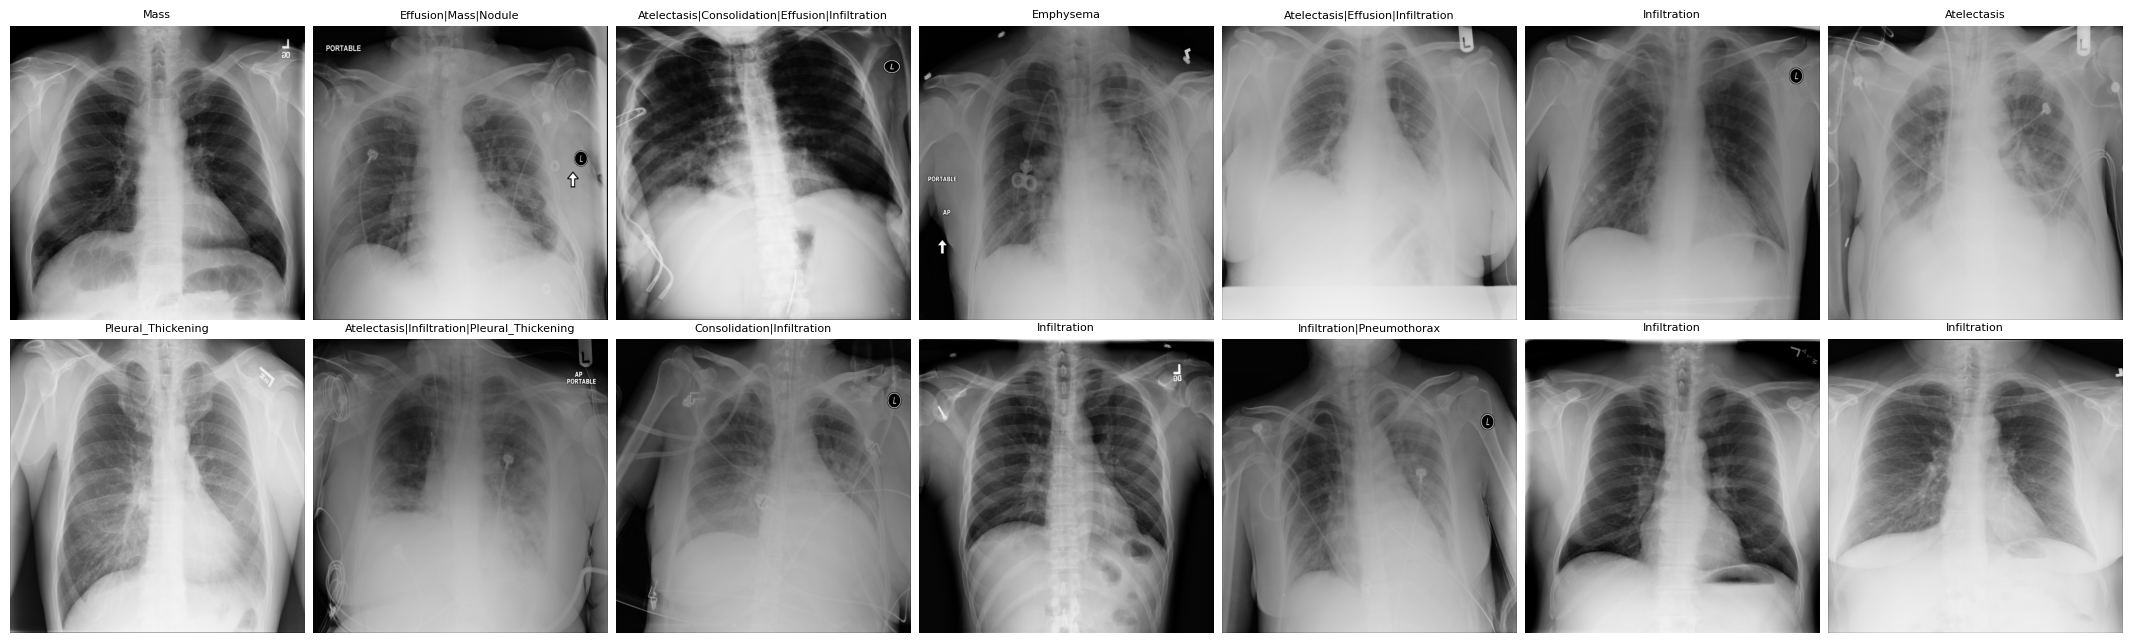

Total cleaned disease rows available: 51759
Displayed images: 14


In [10]:
# Random 14 images with their linked classes (uses all cleaned disease rows)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

if "df_clean" in globals():
    sample_df = df_clean.copy()
elif "df" in globals():
    sample_df = df.copy()
else:
    csv_candidates = [
        Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
        Path("Data_Entry_2017.csv"),
        Path("archive") / "Data_Entry_2017.csv",
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError("Data_Entry_2017.csv not found.")
    sample_df = pd.read_csv(csv_path)

if "Image Index" not in sample_df.columns or "Finding Labels" not in sample_df.columns:
    raise KeyError("Required columns 'Image Index' and/or 'Finding Labels' are missing.")

sample_df["Finding Labels"] = sample_df["Finding Labels"].fillna("").astype(str).str.strip()
sample_df = sample_df.loc[
    sample_df["Finding Labels"].ne("")
    & ~sample_df["Finding Labels"].str.casefold().eq("no finding")
].copy()

base_candidates = [Path("."), Path("archive")]
image_roots = []
for base in base_candidates:
    image_roots.extend(sorted(base.glob("images_*/images")))
if Path("archive/images_512").exists():
    image_roots.append(Path("archive/images_512"))
if Path("images_512").exists():
    image_roots.append(Path("images_512"))

image_lookup = {}
for root in image_roots:
    for p in root.glob("*.png"):
        image_lookup.setdefault(p.name, p)

sample_df = sample_df[sample_df["Image Index"].astype(str).isin(image_lookup.keys())].copy()

n = min(14, len(sample_df))
if n == 0:
    raise ValueError("No images available to display after filtering and path matching.")

selected = sample_df.sample(n=n, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(2, 7, figsize=(22, 7))
axes = axes.flatten()

for ax, (_, row) in zip(axes, selected.iterrows()):
    img_path = image_lookup[str(row["Image Index"])]
    im = Image.open(img_path).convert("RGB")
    ax.imshow(im)
    ax.set_title(str(row["Finding Labels"]), fontsize=8)
    ax.axis("off")

fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.04, wspace=0.03, hspace=0.01)
plt.show()

print(f"Total cleaned disease rows available: {len(sample_df)}")
print(f"Displayed images: {len(selected)}")

## Data Splitting:


The cleaned dataset is highly imbalanced, with some disease classes containing many more images than others. A stratified split was used to preserve the class distribution across the training, validation, and test sets. This makes the evaluation more reliable and reduces the risk of rare classes being underrepresented in one of the splits.  


Aso a small subset of 2000 images was used for the first experiment to test the pipeline and verify that preprocessing, label mapping, training, and evaluation worked correctly.  
This subset was not intended for final performance conclusions. After validating the workflow, the model can be scaled to the full cleaned dataset for the actual experiment.

In [11]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

if "df_clean" in globals():
    split_source_df = df_clean.copy()
elif "df" in globals():
    split_source_df = df.copy()
else:
    csv_candidates = [
        Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
        Path("Data_Entry_2017.csv"),
        Path("archive") / "Data_Entry_2017.csv",
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError("Could not find Data_Entry_2017.csv")
    split_source_df = pd.read_csv(csv_path)

required_cols = ["Finding Labels", "Image Index"]
missing_cols = [c for c in required_cols if c not in split_source_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns for split: {missing_cols}")

work_df = split_source_df.copy()
work_df["Finding Labels"] = work_df["Finding Labels"].fillna("").astype(str).str.strip()
work_df = work_df.loc[
    work_df["Finding Labels"].ne("")
    & ~work_df["Finding Labels"].str.casefold().eq("no finding")
].copy()

# Keep the original multi-label text for training, but stratify on a single primary label.
work_df["primary_label"] = work_df["Finding Labels"].str.split("|").str[0].str.strip()
work_df = work_df.loc[work_df["primary_label"].ne("")].copy()

class_counts = work_df["primary_label"].value_counts().sort_index()
if class_counts.size != 14:
    print(f"Warning: found {class_counts.size} classes instead of 14.")

min_required = 3
rare_classes = class_counts[class_counts < min_required]
if not rare_classes.empty:
    raise ValueError(
        f"Need at least {min_required} samples per class for stable train/val/test stratification. "
        f"Classes below minimum: {rare_classes.to_dict()}"
    )

sample_df = work_df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

train_df, temp_df = train_test_split(
    sample_df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=sample_df["primary_label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=temp_df["primary_label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Classes found: {class_counts.size}")
print(f"Total samples used: {len(sample_df)}")
print("This split keeps all disease images and preserves class proportions.")
print(f"Train size: {len(train_df)} ({len(train_df)/len(sample_df):.2%})")
print(f"Val size:   {len(val_df)} ({len(val_df)/len(sample_df):.2%})")
print(f"Test size:  {len(test_df)} ({len(test_df)/len(sample_df):.2%})")

summary_df = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "pct": [
            len(train_df) / len(sample_df),
            len(val_df) / len(sample_df),
            len(test_df) / len(sample_df),
        ],
    }
)
display(summary_df)

overall_dist = sample_df["primary_label"].value_counts(normalize=True).sort_index()
train_dist = train_df["primary_label"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)
val_dist = val_df["primary_label"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)
test_dist = test_df["primary_label"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)

dist_check = pd.DataFrame(
    {
        "overall": overall_dist,
        "train": train_dist,
        "val": val_dist,
        "test": test_dist,
    }
).round(4)

display(dist_check)

Classes found: 14
Total samples used: 51759
This split keeps all disease images and preserves class proportions.
Train size: 38819 (75.00%)
Val size:   7764 (15.00%)
Test size:  5176 (10.00%)


,split,rows,pct
0,train,38819,0.749995
1,val,7764,0.150003
2,test,5176,0.100002


,overall,train,val,test
primary_label,,,,
Atelectasis,0.2231,0.2231,0.2231,0.2230
Cardiomegaly,0.0464,0.0464,0.0465,0.0464
Consolidation,0.0644,0.0643,0.0644,0.0643
Edema,0.0360,0.0360,0.0361,0.0359
Effusion,0.1553,0.1553,0.1553,0.1553
Emphysema,0.0335,0.0335,0.0335,0.0334
Fibrosis,0.0235,0.0235,0.0234,0.0236
Hernia,0.0030,0.0030,0.0030,0.0031
Infiltration,0.2279,0.2279,0.2278,0.2280


--------------------------------

# classifier  

In [14]:
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader
import lightning as L
import torchvision
from torchvision import transforms
from torchmetrics.classification import MultilabelAccuracy, MultilabelPrecision, MultilabelRecall

L.seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if "train_df" not in globals() or "val_df" not in globals() or "test_df" not in globals():
    raise RuntimeError("train_df/val_df/test_df not found. Run the Data Splitting cell first.")

label_col = "Finding Labels"
image_col = "Image Index"

for col in [label_col, image_col]:
    if col not in train_df.columns:
        raise KeyError(f"Column '{col}' is missing from train_df.")

def discover_image_lookup() -> dict:
    def is_valid_image(img_path: Path) -> bool:
        try:
            with Image.open(img_path) as img:
                img.convert("RGB").load()
            return True
        except (UnidentifiedImageError, OSError, ValueError):
            return False

    roots = []
    candidates = [Path("archive") / "images_512", Path("images_512")]
    for p in candidates:
        if p.exists():
            roots.append(p)

    for base in [Path("."), Path("archive")]:
        roots.extend(sorted(base.glob("images_*/images")))

    lookup = {}
    for root in roots:
        for img_path in root.glob("*.png"):
            if img_path.name in lookup:
                continue
            if is_valid_image(img_path):
                lookup[img_path.name] = img_path
            else:
                print(f"Skipping unreadable image: {img_path}")
    return lookup

image_lookup = discover_image_lookup()
if not image_lookup:
    raise FileNotFoundError("No valid image files found in images_512 or images_*/images folders.")

# Build the 14 NIH label vocabulary from the full multi-label strings.
def extract_labels(label_text: str) -> list[str]:
    return [label.strip() for label in str(label_text).split("|") if label.strip()]

all_labels = sorted(
    {
        label
        for frame in [train_df, val_df, test_df]
        for label_text in frame[label_col].astype(str)
        for label in extract_labels(label_text)
        if label.casefold() != "no finding"
    }
)
label_to_idx = {label: i for i, label in enumerate(all_labels)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
num_labels = len(all_labels)
print(f"Number of labels: {num_labels}")

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split_df[label_col] = split_df[label_col].astype(str).str.strip()
    split_df["_image_path"] = split_df[image_col].astype(str).map(image_lookup)
    before_rows = len(split_df)
    split_df.dropna(subset=["_image_path"], inplace=True)
    dropped = before_rows - len(split_df)
    if dropped > 0:
        print(f"{split_name}: dropped {dropped} rows because the image file was missing or unreadable.")

# Multi-hot targets for the multilabel classifier.
def encode_labels(label_text: str) -> torch.Tensor:
    target = torch.zeros(num_labels, dtype=torch.float32)
    for label in extract_labels(label_text):
        if label in label_to_idx:
            target[label_to_idx[label]] = 1.0
    return target

train_targets = torch.stack([encode_labels(text) for text in train_df[label_col].tolist()])
pos_counts = train_targets.sum(dim=0)
neg_counts = train_targets.shape[0] - pos_counts
pos_weight = torch.where(pos_counts > 0, neg_counts / pos_counts, torch.zeros_like(pos_counts))
pos_weight = pos_weight.clamp(max=20.0)

class XrayDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        try:
            with Image.open(row["_image_path"]) as img:
                image = img.convert("RGB")
        except (UnidentifiedImageError, OSError, ValueError) as exc:
            raise RuntimeError(f"Unreadable image file: {row['_image_path']}") from exc
        if self.transform is not None:
            image = self.transform(image)
        target = encode_labels(row[label_col])
        return image, target

# Keep original 512x512 input size for EfficientNetV2-S.
train_tfms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(7),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = XrayDataset(train_df, transform=train_tfms)
val_ds = XrayDataset(val_df, transform=val_test_tfms)
test_ds = XrayDataset(test_df, transform=val_test_tfms)

batch_size = 32
num_workers = 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

class XrayClassifier(L.LightningModule):
    def __init__(self, n_labels: int, pos_weight: torch.Tensor | None = None, lr: float = 1e-4):
        super().__init__()
        self.save_hyperparameters(ignore=["pos_weight"])
        self.backbone = torchvision.models.efficientnet_v2_s(weights="DEFAULT")
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone.features[-1].parameters():
            param.requires_grad = True
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, n_labels),
        )
        if pos_weight is not None:
            self.register_buffer("pos_weight", pos_weight)
        else:
            self.pos_weight = None
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)
        self.train_acc = MultilabelAccuracy(num_labels=n_labels, threshold=0.5, average="micro")
        self.val_acc = MultilabelAccuracy(num_labels=n_labels, threshold=0.5, average="micro")
        self.val_precision = MultilabelPrecision(num_labels=n_labels, threshold=0.5, average="micro")
        self.val_recall = MultilabelRecall(num_labels=n_labels, threshold=0.5, average="micro")

    def forward(self, x):
        return self.backbone(x)

    def training_step(self, batch, batch_idx):
        images, targets = batch
        logits = self(images)
        loss = self.criterion(logits, targets)
        probs = torch.sigmoid(logits)
        self.train_acc(probs, targets.int())
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, targets = batch
        logits = self(images)
        loss = self.criterion(logits, targets)
        probs = torch.sigmoid(logits)
        self.val_acc(probs, targets.int())
        self.val_precision(probs, targets.int())
        self.val_recall(probs, targets.int())
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_precision", self.val_precision, on_step=False, on_epoch=True, prog_bar=False)
        self.log("val_recall", self.val_recall, on_step=False, on_epoch=True, prog_bar=False)

    def configure_optimizers(self):
        return torch.optim.AdamW(
            [
                {"params": self.backbone.features[-1].parameters(), "lr": self.hparams.lr * 0.1},
                {"params": self.backbone.classifier.parameters(), "lr": self.hparams.lr},
            ],
            weight_decay=1e-4,
        )

model = XrayClassifier(n_labels=num_labels, pos_weight=pos_weight, lr=1e-4)


Seed set to 42


Seed set to 42


Using device: cuda
Skipping unreadable image: archive\images_512\00000213_004.png
Number of labels: 14
train: dropped 1 rows because the image file was missing or unreadable.
Train batches: 4853 | Val batches: 971 | Test batches: 647


# Training

In [15]:
# Pre-flight checks so trainer.fit fails with clear messages.
required_objs = ["model", "train_loader", "val_loader", "trainer_kwargs"]
missing = [name for name in required_objs if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects before training: {missing}. Run classifier and setup cells first.")

if len(train_loader) == 0 or len(val_loader) == 0:
    raise RuntimeError("train_loader or val_loader is empty. Check split/filter logic and image paths.")

logger = CSVLogger(save_dir="archive", name="xray_training_logs")
early_stop = EarlyStopping(monitor="val_loss", mode="min", patience=4)

trainer = L.Trainer(
    max_epochs=12,
    logger=logger,
    callbacks=[early_stop],
    enable_checkpointing=True,
    log_every_n_steps=5,
    **trainer_kwargs,
)

try:
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
except RuntimeError as e:
    msg = str(e)
    if "out of memory" in msg.lower():
        raise RuntimeError(
            "CUDA out of memory during trainer.fit. Reduce batch_size in the classifier cell (for 512x512 start with 4 or 8), then re-run classifier and training cells."
        ) from e
    raise

print(f"Training complete. Logs: {trainer.logger.log_dir}")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone      │ EfficientNet        │ 20.2 M │ train │     0 │
│ 1 │ criterion     │ BCEWithLogitsLoss   │      0 │ train │     0 │
│ 2 │ train_acc     │ MultilabelAccuracy  │      0 │ train │     0 │
│ 3 │ val_acc       │ MultilabelAccuracy  │      0 │ train │     0 │
│ 4 │ val_precision │ MultilabelPrecision │      0 │ train │     0 │
│ 5 │ val_recall    │ MultilabelRecall    │      0 │ train │     0 │
└───┴───────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 348 K                                                                                            
Non-trainable params: 19.8 M                                                                                       
Total params: 20.2 M                                                                                               
Total estimated model params size (MB): 80                                                                         
Modules in train mode: 719                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rich\live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rich\live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_c
onnector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the
value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_c
onnector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

Training complete. Logs: archive\xray_training_logs\version_16


# validation chart 

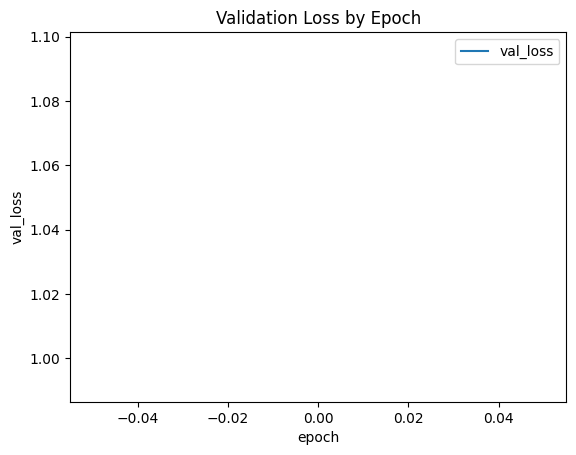

In [16]:
import os
import pandas as pd

if "trainer" not in globals() or getattr(trainer, "logger", None) is None:
    raise RuntimeError("Trainer/logs not found. Run the Training cell first.")

metrics = pd.read_csv(os.path.join(trainer.logger.log_dir, "metrics.csv"))
loss_metrics = metrics[["epoch", "val_loss"]].dropna(subset=["val_loss"]).set_index("epoch")
plot = loss_metrics.plot(title="Validation Loss by Epoch", ylabel="val_loss")

# Overall Metrics

In [ ]:
import torch
from sklearn.metrics import classification_report
import numpy as np

if "model" not in globals() or "test_loader" not in globals():
    raise RuntimeError("Model or test_loader not found. Run the Training cell first.")

eval_device = next(model.parameters()).device
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(eval_device)
        targets = targets.to(eval_device)
        logits = model(images)
        preds = (torch.sigmoid(logits) >= 0.5).int()
        all_preds.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy().astype(int))

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

exact_match = (all_preds == all_targets).all(axis=1).mean() if len(all_targets) else 0.0
print(f"Test samples: {len(all_targets)}")
print(f"Exact match accuracy: {exact_match:.4f} ({exact_match:.2%})")
print("\n" + "=" * 80)
print("Per-label Precision, Recall, and F1-Score:")
print("=" * 80)

if "idx_to_label" in globals():
    class_names = [idx_to_label[i] for i in range(len(idx_to_label))]
else:
    class_names = None

print(classification_report(all_targets, all_preds, target_names=class_names, zero_division=0))